# $(SASA) Regular$

$loss = \alpha \times mse(\hat{\theta_i^a}, \hat{\theta_j^a}) + \beta \times (1-mse(\hat{\theta_i^a}, \hat{\theta_k^b})) + \gamma \times mse(\hat{s_{i+2}^a}, y) + \lambda(\hat{\theta_i^a}^2 + \hat{\theta_k^b}^2 + \hat{\theta_j^a}^2)$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='training_data_short.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
173,28,7,"(0.27, 1.1)","(0.259, 1.169, -0.12, -0.867)",1,1.0,"(0.282, 1.358, -0.138, -1.037)",1.0,1.0,"(0.309, 1.547, -0.158, -1.209)"
32,2,3,"(0.05, 1.7)","(-0.046, -0.398, 0.032, 0.18)",1,1.0,"(-0.054, -0.212, 0.036, 0.1)",0.0,1.0,"(-0.058, -0.398, 0.038, 0.186)"
38,8,3,"(0.05, 1.7)","(-0.09, -0.028, 0.053, 0.036)",1,1.0,"(-0.091, 0.158, 0.054, -0.043)",1.0,1.0,"(-0.088, 0.343, 0.053, -0.121)"
136,52,5,"(0.63, 1.5)","(0.156, 0.8, -0.162, -0.966)",1,1.0,"(0.172, 0.99, -0.181, -1.147)",0.0,1.0,"(0.192, 0.803, -0.204, -1.024)"
6,6,0,"(0.24, 0.6)","(-0.025, 0.036, -0.0, 0.026)",0,1.0,"(-0.024, -0.158, 0.0, 0.298)",0.0,1.0,"(-0.027, -0.352, 0.006, 0.57)"
...,...,...,...,...,...,...,...,...,...,...
137,53,5,"(0.63, 1.5)","(0.172, 0.99, -0.181, -1.147)",0,1.0,"(0.192, 0.803, -0.204, -1.024)",1.0,1.0,"(0.208, 0.993, -0.225, -1.209)"
200,13,9,"(0.11, 0.5)","(0.016, -0.22, 0.047, 0.4)",0,1.0,"(0.011, -0.416, 0.055, 0.71)",0.0,1.0,"(0.003, -0.612, 0.07, 1.021)"
57,27,3,"(0.05, 1.7)","(0.214, 1.271, -0.064, -0.527)",1,1.0,"(0.24, 1.456, -0.075, -0.615)",0.0,1.0,"(0.269, 1.271, -0.087, -0.539)"
74,1,4,"(0.93, 1.7)","(0.044, -0.191, 0.047, 0.187)",0,1.0,"(0.041, -0.383, 0.051, 0.417)",0.0,1.0,"(0.033, -0.576, 0.059, 0.646)"


In [3]:
model = Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=2000, alpha=loss_param, beta=loss_param, lambda_=loss_param)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_positive,mse_negative,mse_s,regularize,transition,reward
0,0,"[0.37604179978370667, 1.2865437269210815]","[0.31356993317604065, 1.141424536705017]","[0.08457392454147339, 0.6206964254379272, 0.09...",1.746454,1.704791,0.828233
1,1,"[0.37686625123023987, 1.2942237854003906]","[0.31442439556121826, 1.1483228206634521]","[0.08312315493822098, 0.6123796105384827, 0.08...",1.745759,1.687673,0.828276
2,2,"[0.3776865005493164, 1.3019813299179077]","[0.3152436316013336, 1.1552557945251465]","[0.08170364797115326, 0.6041824221611023, 0.08...",1.745085,1.670795,0.828363
3,3,"[0.3785226047039032, 1.3097467422485352]","[0.31608521938323975, 1.1621829271316528]","[0.08031187951564789, 0.5961111783981323, 0.08...",1.744438,1.654150,0.828503
4,4,"[0.3793810307979584, 1.3175050020217896]","[0.316957950592041, 1.1691107749938965]","[0.07894731312990189, 0.5881632566452026, 0.08...",1.743818,1.637735,0.828695


In [4]:
data.training_dataset.head()

,step,episode,p,s,a,r,s_,a_,r_,s__
173,28,7,"(0.27, 1.1)","(0.259, 1.169, -0.12, -0.867)",1,1.0,"(0.282, 1.358, -0.138, -1.037)",1.0,1.0,"(0.309, 1.547, -0.158, -1.209)"
32,2,3,"(0.05, 1.7)","(-0.046, -0.398, 0.032, 0.18)",1,1.0,"(-0.054, -0.212, 0.036, 0.1)",0.0,1.0,"(-0.058, -0.398, 0.038, 0.186)"
38,8,3,"(0.05, 1.7)","(-0.09, -0.028, 0.053, 0.036)",1,1.0,"(-0.091, 0.158, 0.054, -0.043)",1.0,1.0,"(-0.088, 0.343, 0.053, -0.121)"
136,52,5,"(0.63, 1.5)","(0.156, 0.8, -0.162, -0.966)",1,1.0,"(0.172, 0.99, -0.181, -1.147)",0.0,1.0,"(0.192, 0.803, -0.204, -1.024)"
6,6,0,"(0.24, 0.6)","(-0.025, 0.036, -0.0, 0.026)",0,1.0,"(-0.024, -0.158, 0.0, 0.298)",0.0,1.0,"(-0.027, -0.352, 0.006, 0.57)"


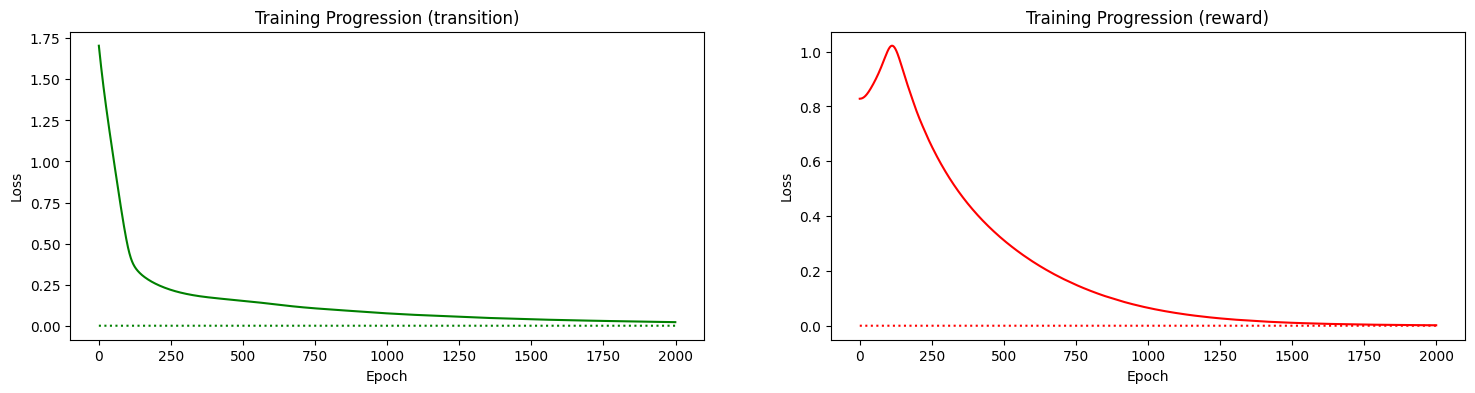

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

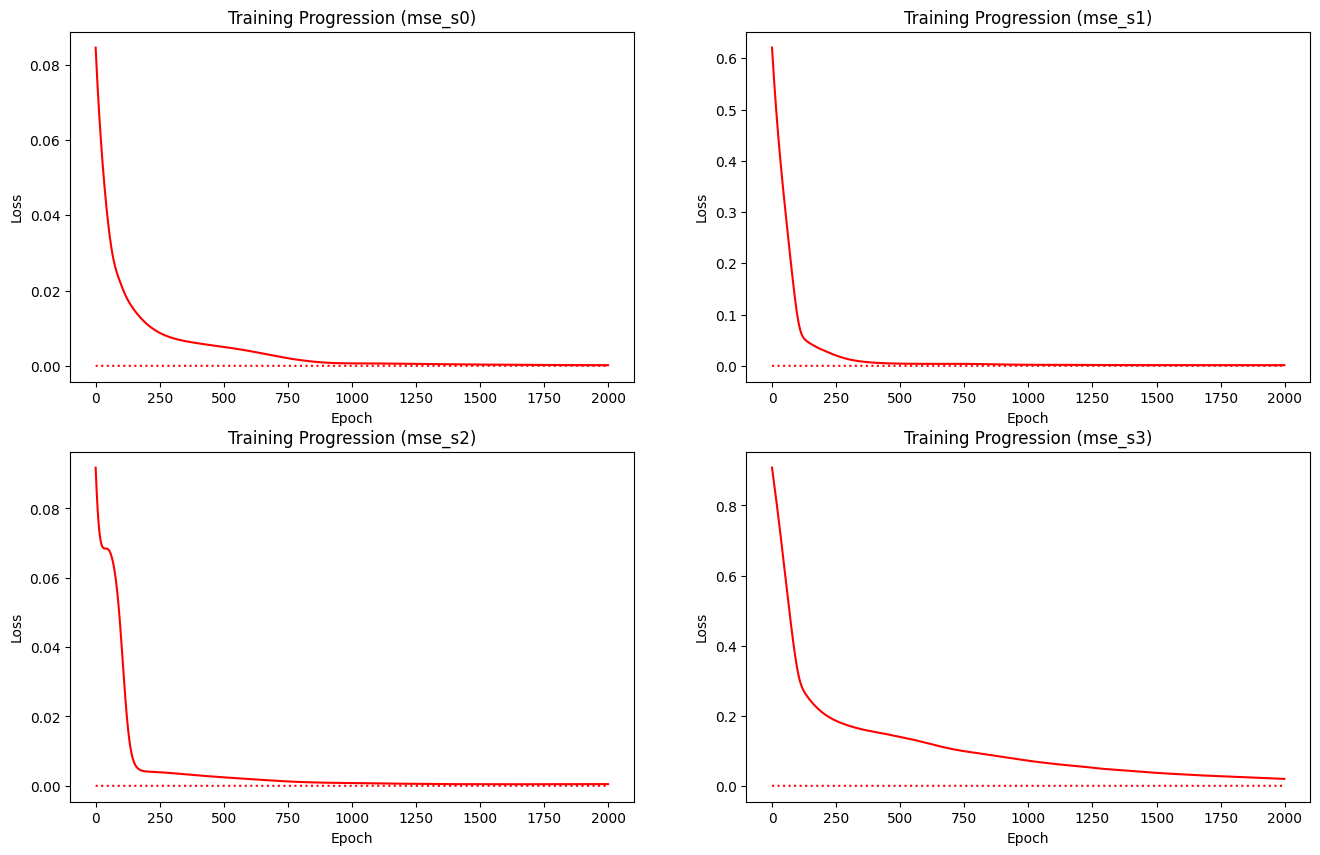

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

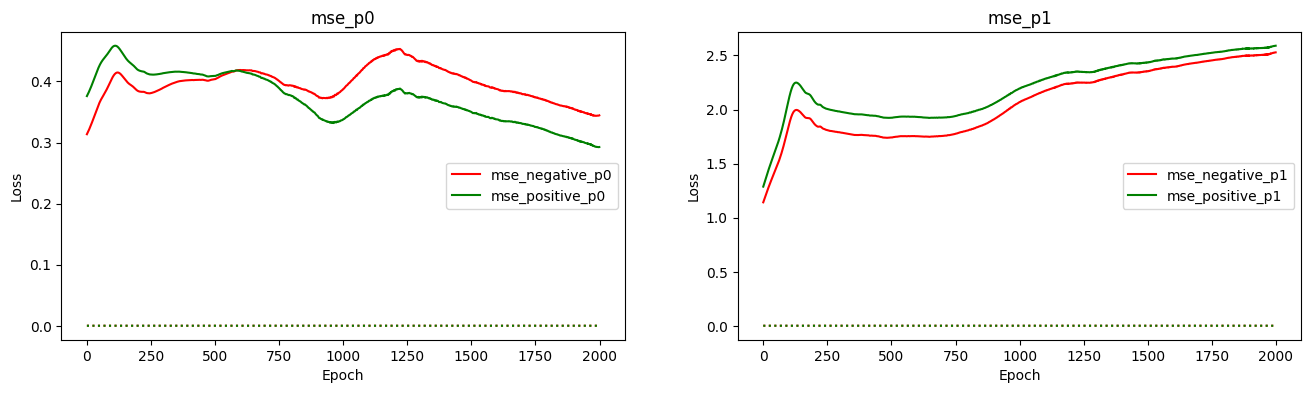

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,(neg, pos) in enumerate(zip(expansions['mse_negative'], expansions['mse_positive'])):
    data.plot_training_loss(axs[i], df[neg], 'r')
    data.plot_training_loss(axs[i], df[pos], 'g')
    axs[i].set_title(f'mse_p{i}')
    axs[i].legend()

plt.show()

## Params

In [8]:
import pandas as pd

training_params = pd.DataFrame(y.numpy(), columns=model.targets_lables)

expansions = {
    'p': ['p0', 'p1']
}
df_trainning = get_data_expanded(data.training_data.loc[(data.training_data.epoch==499)], expansions)

df_trainning_p = pd.DataFrame([], columns=['epoch', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1', 'p0', 'p1'])
for epoch in df_trainning.epoch.unique():
    copy = df_trainning[df_trainning.epoch == epoch].copy()[['epoch', 'p0', 'p1']].reset_index(drop=True)
    copy[['sample', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']] = training_params.copy()[['positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']].reset_index()
    df_trainning_p = pd.concat([df_trainning_p, copy])

df_trainning_p.head()

/tmp/ipykernel_8843/580248604.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_trainning_p = pd.concat([df_trainning_p, copy])


,epoch,positive_p0,positive_p1,negative_p0,negative_p1,p0,p1,sample
0,499,0.27,1.1,0.63,1.5,-0.597681,-0.581748,0.0
1,499,0.05,1.7,0.11,0.5,0.200333,-0.026171,1.0
2,499,0.05,1.7,0.97,0.2,0.030459,-0.058090,2.0
3,499,0.63,1.5,0.27,1.1,-0.502678,-0.418534,3.0
4,499,0.24,0.6,0.27,1.1,-0.022453,0.093019,4.0


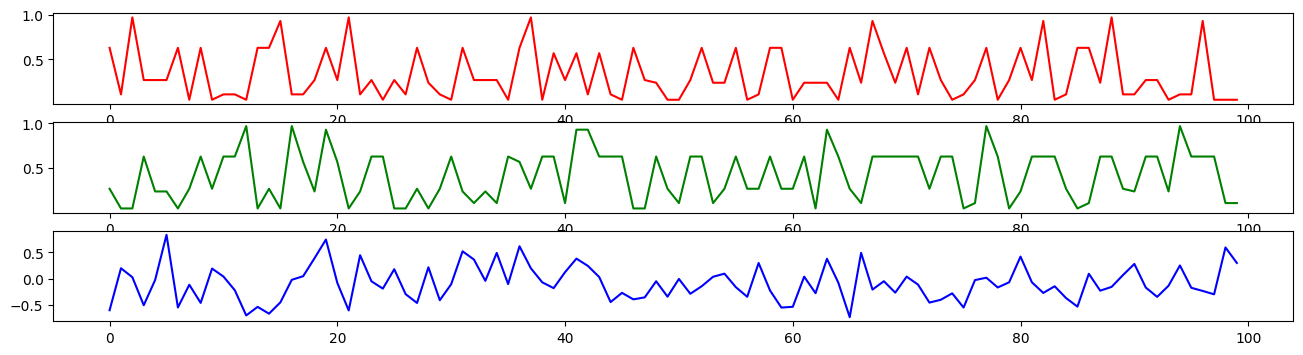

In [9]:
fig, axs = plt.subplots(3, 1, figsize=(16, 4))

axs[0].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['negative_p0'], color='r', label='negative')
axs[1].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['positive_p0'], color='g', label='positve')
axs[2].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['p0'], color='b', label='estimative')

plt.show()

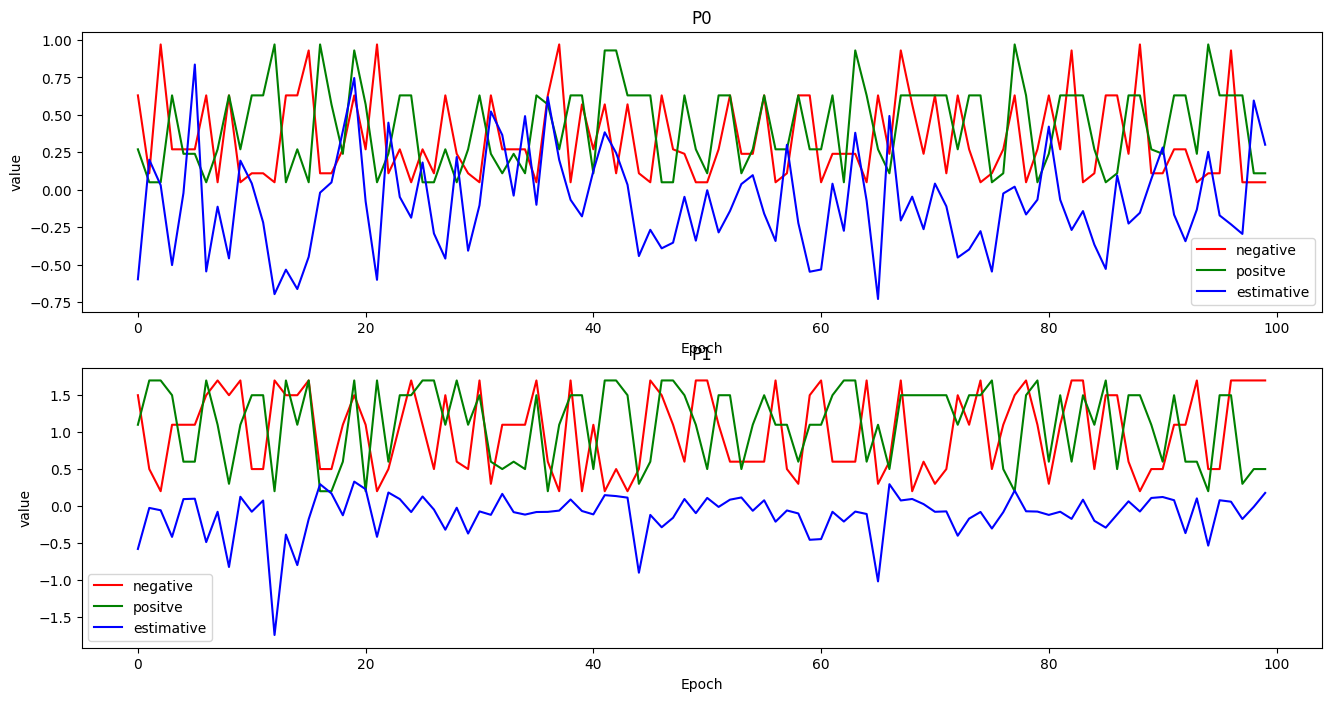

In [10]:
fig, axs = plt.subplots(2,1, figsize=(16, 8))

# df = df_trainning_p.groupby('epoch').mean()
# df = df_trainning_p.groupby('sample').mean()
df = df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]

axs[0].plot(df['negative_p0'], color='r', label='negative')
axs[0].plot(df['positive_p0'], color='g', label='positve')
axs[0].plot(df['p0'], color='b', label='estimative')

axs[0].set_ylabel('value')
axs[0].set_xlabel('Epoch')
axs[0].set_title(f'P0')
axs[0].legend()

axs[1].plot(df['negative_p1'], color='r', label='negative')
axs[1].plot(df['positive_p1'], color='g', label='positve')
axs[1].plot(df['p1'], color='b', label='estimative')

axs[1].set_ylabel('value')
axs[1].set_xlabel('Epoch')
axs[1].set_title(f'P1')
axs[1].legend()

plt.show()

## Best and worst episodes

In [11]:
data.evaluate_model(model, path='training_data_short.csv')
results = data.get_evaluation_metrics()
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_s0,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse
0,0,0,"(0.24, 0.6)","(-0.041, 0.037, 0.015, -0.0)",0,1.0,"(-0.04, -0.157, 0.015, 0.276)",1.0,1.0,"(-0.043, 0.037, 0.02, 0.009)",...,0.005,0.008,0.013,0.019,0.0,0.229199,0.439728,0.525424,0.551664,0.045
1,1,0,"(0.24, 0.6)","(-0.04, -0.157, 0.015, 0.276)",1,1.0,"(-0.043, 0.037, 0.02, 0.009)",1.0,1.0,"(-0.042, 0.231, 0.02, -0.257)",...,0.001,0.016,0.006,0.058,0.0,0.222920,0.442320,0.508475,0.556508,0.081
2,2,0,"(0.24, 0.6)","(-0.043, 0.037, 0.02, 0.009)",1,1.0,"(-0.042, 0.231, 0.02, -0.257)",1.0,1.0,"(-0.038, 0.425, 0.015, -0.523)",...,0.007,0.027,0.004,0.004,0.0,0.232339,0.445885,0.503632,0.549801,0.042
3,3,0,"(0.24, 0.6)","(-0.042, 0.231, 0.02, -0.257)",1,1.0,"(-0.038, 0.425, 0.015, -0.523)",0.0,1.0,"(-0.029, 0.23, 0.005, -0.247)",...,0.008,0.021,0.009,0.033,0.0,0.233909,0.443940,0.515738,0.553403,0.071
4,4,0,"(0.24, 0.6)","(-0.038, 0.425, 0.015, -0.523)",0,1.0,"(-0.029, 0.23, 0.005, -0.247)",0.0,1.0,"(-0.025, 0.036, -0.0, 0.026)",...,0.005,0.015,0.004,0.034,0.0,0.229199,0.441996,0.503632,0.553527,0.058


In [12]:
rmse = results[['episode', 'rse_s0', 'rse_s1', 'rse_s2', 'rse_s3']].groupby('episode').mean().reset_index()
rmse['rmse'] = rmse.rse_s0 + rmse.rse_s1 + rmse.rse_s2 + rmse.rse_s3
rmse_sorted = rmse.sort_values(by='rmse')
epis = rmse.shape[0]

best_episodes = rmse_sorted.head(3).episode.values
worst_episodes = rmse_sorted.tail(3).episode.values
print(f'{best_episodes=}', f'{worst_episodes=}')

best_episodes=array([5, 0, 9]) worst_episodes=array([1, 2, 6])


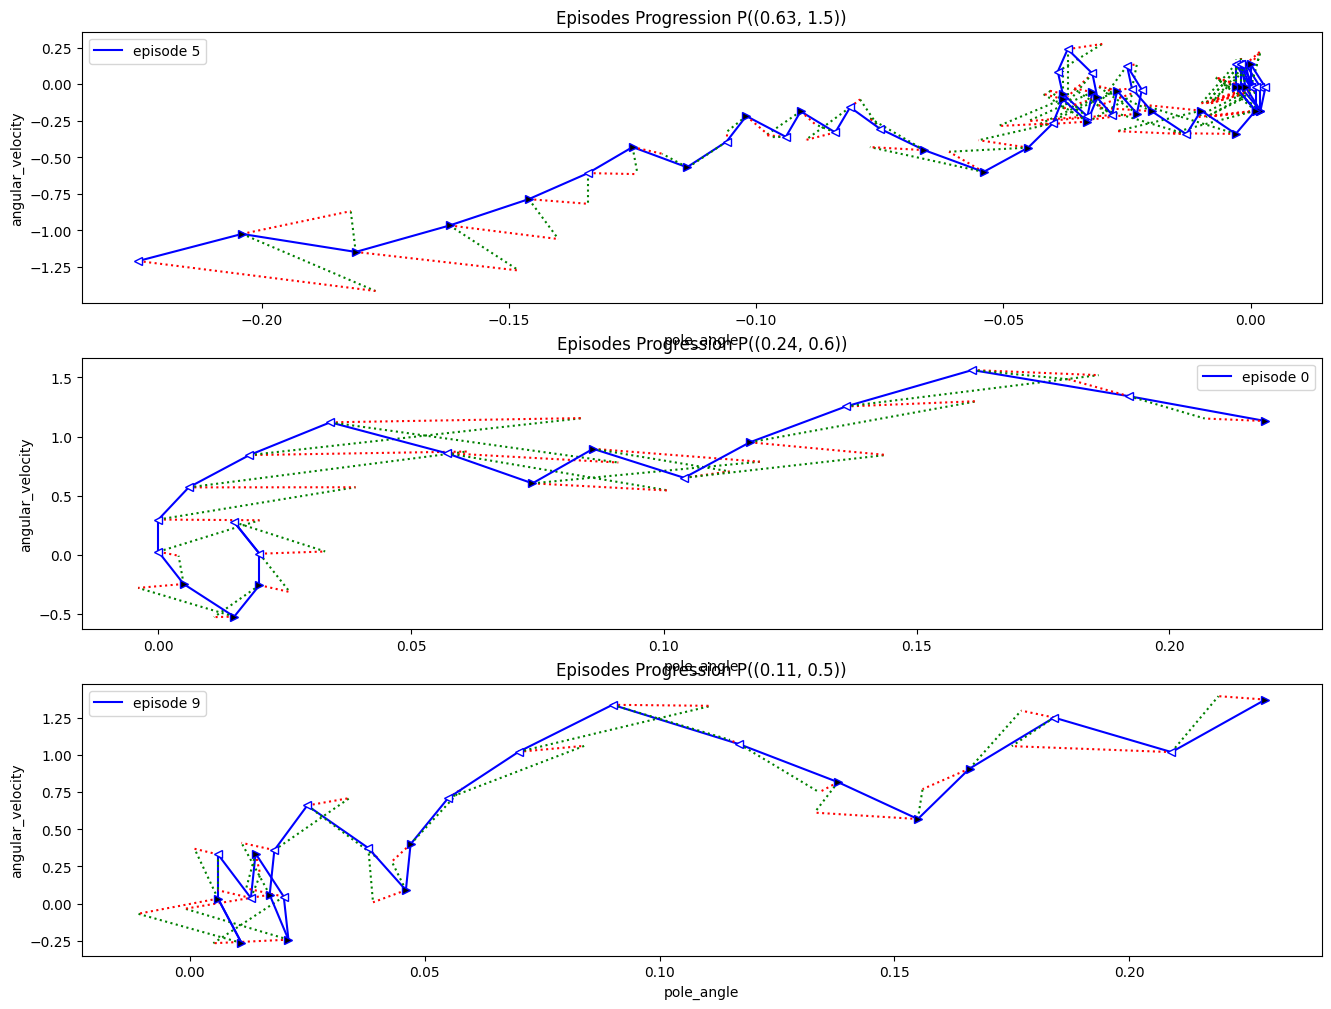

In [13]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(best_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

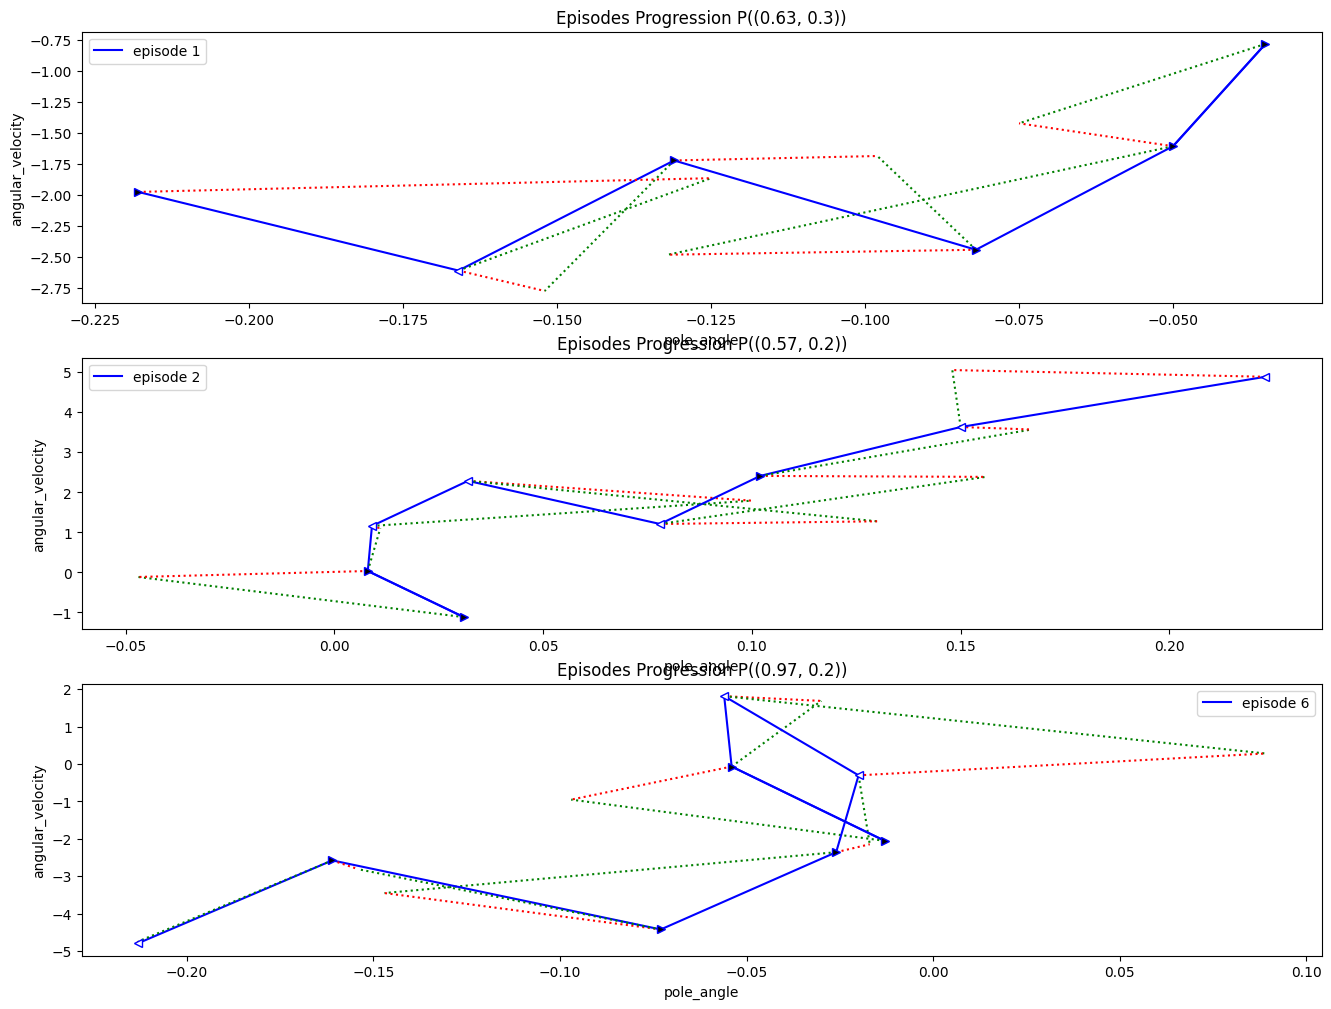

In [14]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(worst_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

## Kmeans

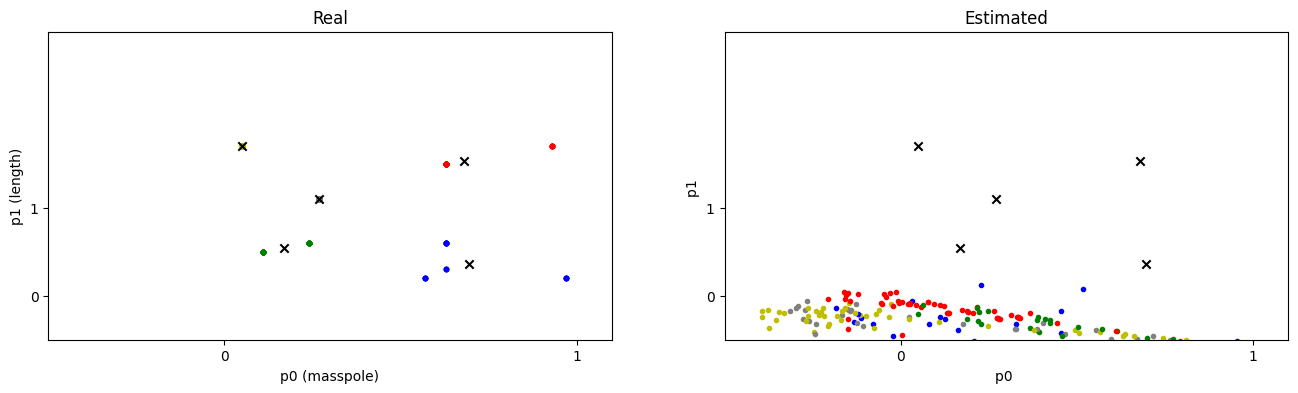

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
data.plot_clusters(axs, results)
plt.show()

# Evaluation

In [77]:
data.evaluate_model(model, path='testing_data_short.csv')
results = data.get_evaluation_metrics()
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_s0,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse
0,0,0,"(0.27, 1.9)","(-0.037, 0.026, -0.021, 0.016)",0,1.0,"(-0.036, -0.159, -0.02, 0.102)",0.0,1.0,"(-0.04, -0.345, -0.018, 0.188)",...,0.010,0.019,0.036,0.034,0.1,0.933014,0.597535,0.320,0.251827,0.099
1,1,0,"(0.27, 1.9)","(-0.036, -0.159, -0.02, 0.102)",0,1.0,"(-0.04, -0.345, -0.018, 0.188)",0.0,1.0,"(-0.047, -0.531, -0.014, 0.274)",...,0.011,0.038,0.036,0.076,0.1,0.935407,0.607717,0.320,0.279734,0.161
2,2,0,"(0.27, 1.9)","(-0.04, -0.345, -0.018, 0.188)",0,1.0,"(-0.047, -0.531, -0.014, 0.274)",1.0,1.0,"(-0.057, -0.345, -0.009, 0.185)",...,0.016,0.023,0.021,0.188,0.1,0.947368,0.599678,0.260,0.354153,0.248
3,3,0,"(0.27, 1.9)","(-0.047, -0.531, -0.014, 0.274)",1,1.0,"(-0.057, -0.345, -0.009, 0.185)",0.0,1.0,"(-0.064, -0.531, -0.005, 0.272)",...,0.010,0.056,0.037,0.242,0.1,0.933014,0.617363,0.324,0.390033,0.345
4,4,0,"(0.27, 1.9)","(-0.057, -0.345, -0.009, 0.185)",0,1.0,"(-0.064, -0.531, -0.005, 0.272)",1.0,1.0,"(-0.075, -0.345, 0.0, 0.183)",...,0.017,0.028,0.021,0.152,0.1,0.949761,0.602358,0.260,0.330233,0.218


In [78]:
results[['rse_s0','rse_s1','rse_s2','rse_s3','rse_r','rse_s0_normalized','rse_s1_normalized','rse_s2_normalized','rse_s3_normalized', 'rse']].describe()

,rse_s0,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse
count,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000
mean,0.013358,0.060682,0.023270,0.365399,0.079054,0.941048,0.619873,0.269081,0.472026,0.462709
std,0.009831,0.057553,0.013764,0.423144,0.040830,0.023518,0.030843,0.055056,0.281159,0.477331
min,0.000000,0.002000,0.000000,0.001000,0.000000,0.909091,0.588424,0.176000,0.229900,0.039000
25%,0.006000,0.023750,0.014000,0.097500,0.100000,0.923445,0.600080,0.232000,0.294020,0.154750
50%,0.011000,0.042000,0.021500,0.191000,0.100000,0.935407,0.609861,0.262000,0.356146,0.248500
75%,0.017000,0.079500,0.030000,0.463000,0.100000,0.949761,0.629957,0.296000,0.536877,0.570500
max,0.046000,0.271000,0.061000,1.973000,0.100000,1.019139,0.732583,0.420000,1.540199,2.211000


/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/pyt

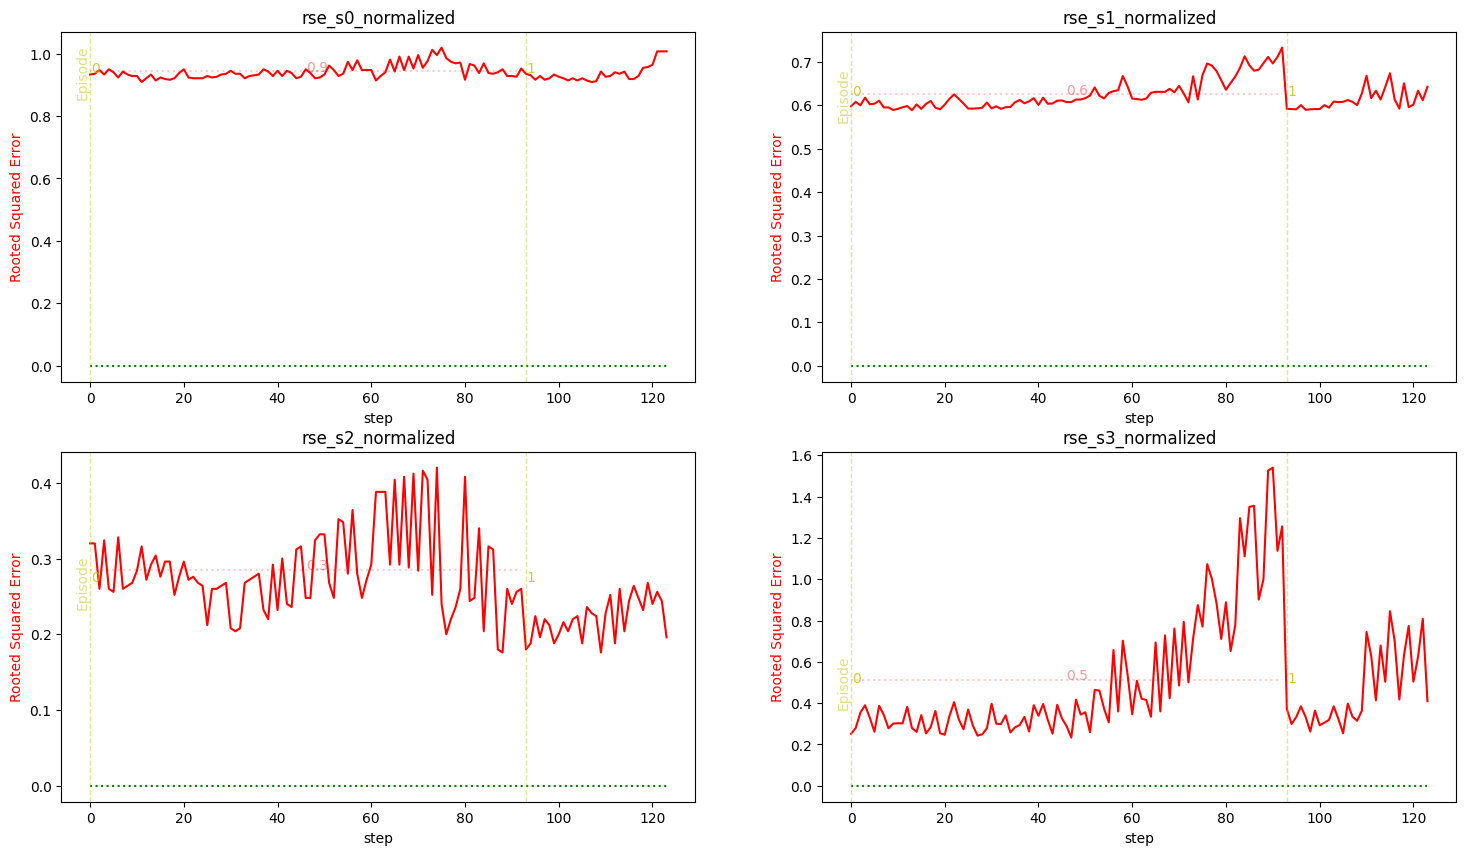

In [99]:
n = 2

df = results[['episode', 'rse']].groupby("episode").mean().reset_index()
worst = df.loc[df.rank(ascending=False)['rse']<=n].episode
df = results[results['episode'].isin(worst)].reset_index(drop=True)


fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], df, 'rse_s0_normalized')
data.plot_value_through_episodes(axs[0][1], df, 'rse_s1_normalized')
data.plot_value_through_episodes(axs[1][0], df, 'rse_s2_normalized')
data.plot_value_through_episodes(axs[1][1], df, 'rse_s3_normalized')

plt.show()

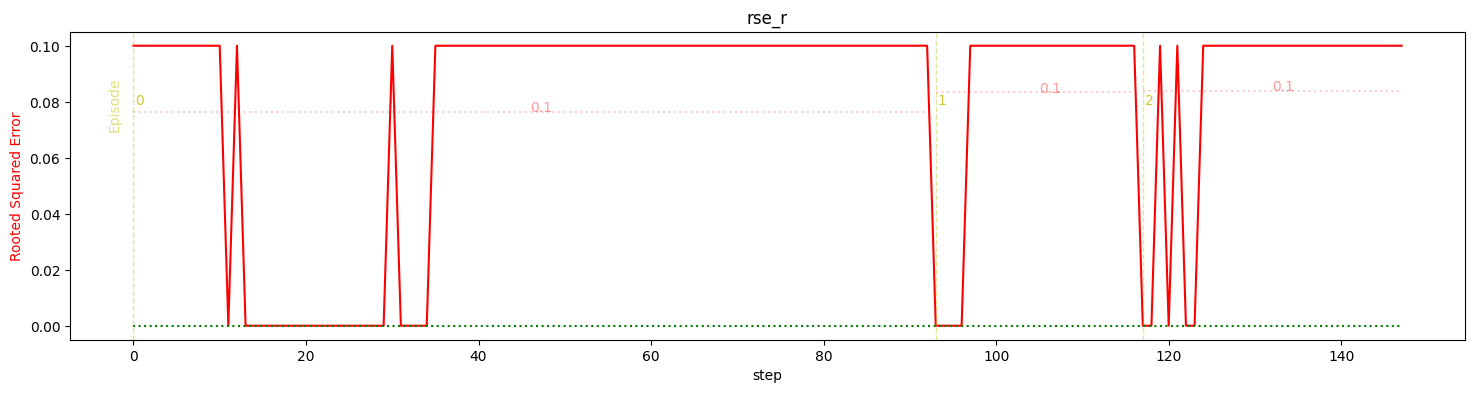

In [19]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

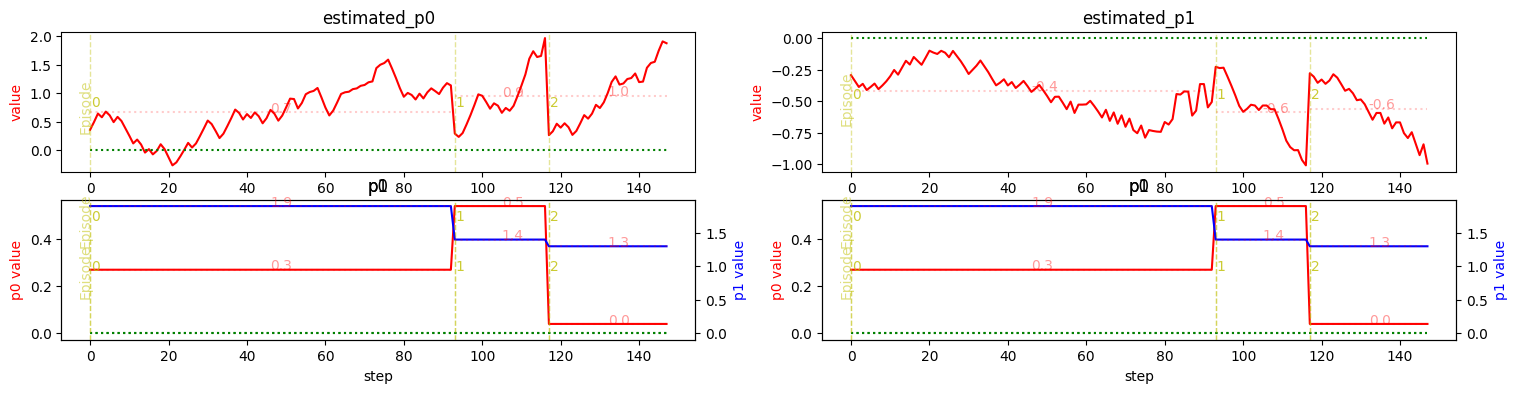

In [70]:
import numpy as np

n = 3

df = results[['episode', 'estimated_p0', 'estimated_p1', 'p0', 'p1']].groupby("episode").mean().reset_index()
df['dist_p0'] = np.sqrt(np.pow(df['estimated_p0']-df['p0'], 2))
df['dist_p1'] = np.sqrt(np.pow(df['estimated_p1']-df['p1'], 2))
df['dist'] = df['dist_p0'] + df['dist_p1']
worst = df.loc[df.rank(ascending=False)['dist']<=n].episode
df = results[results['episode'].isin(worst)].reset_index(drop=True)

fig, axs = plt.subplots(2, 2, figsize=(18,4))
data.plot_value_through_episodes(axs[0][0], df, 'estimated_p0', y_label='value')
data.plot_value_through_episodes(axs[0][1], df, 'estimated_p1', y_label='value')

data.plot_value_through_episodes(axs[1][0], df, 'p0', y_label='p0 value')
data.plot_value_through_episodes(axs[1][0].twinx(), df, 'p1', y_label='p1 value', color='b')

data.plot_value_through_episodes(axs[1][1], df, 'p0', y_label='p0 value')
data.plot_value_through_episodes(axs[1][1].twinx(), df, 'p1', y_label='p1 value', color='b')

plt.show()

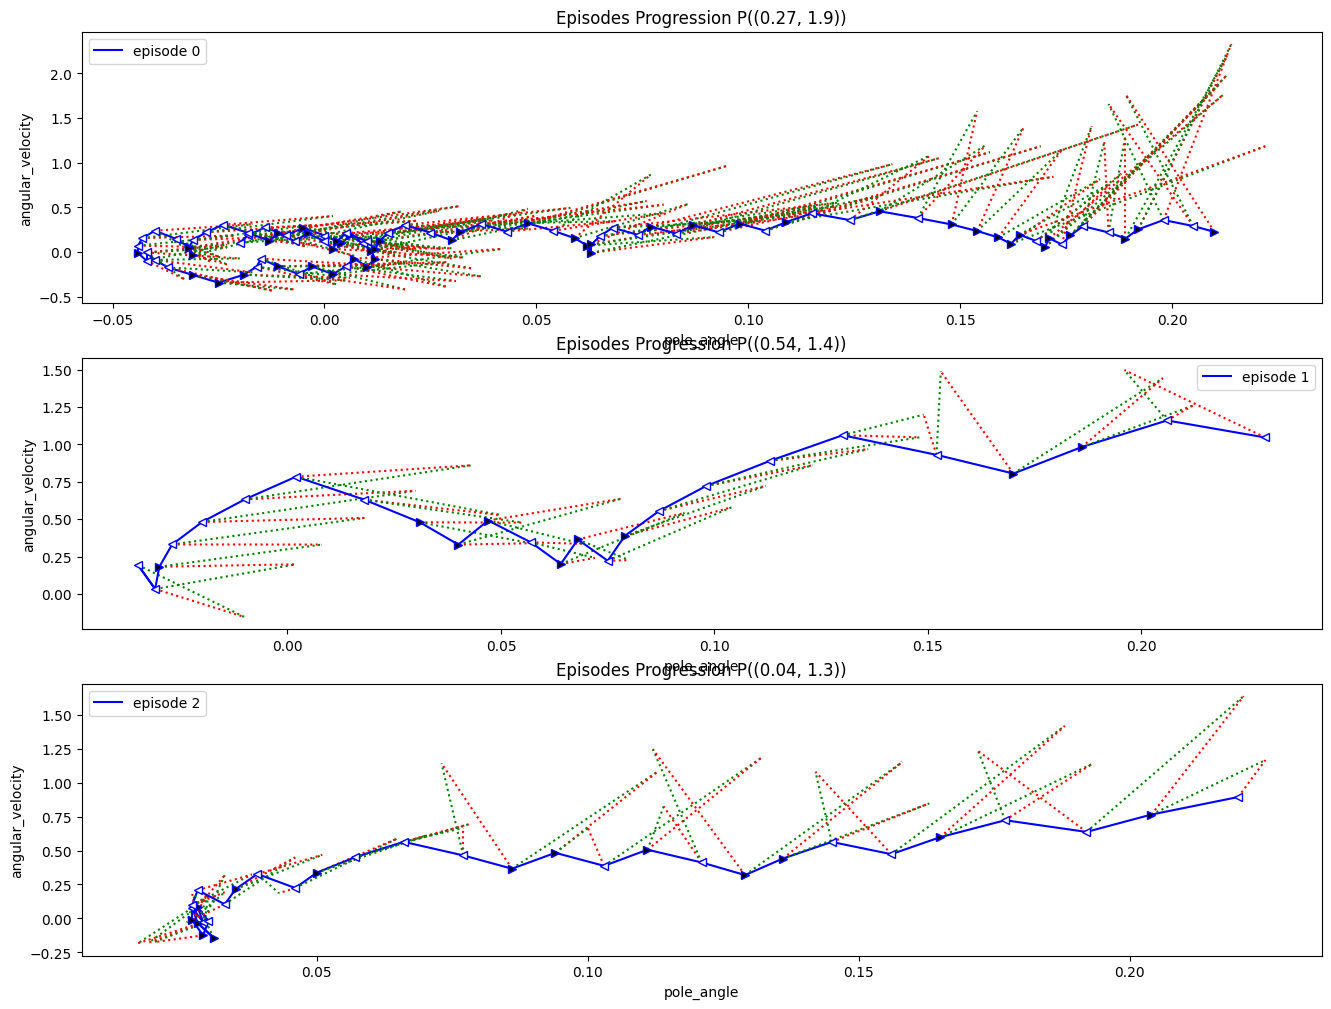

In [21]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()

## Cluster

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


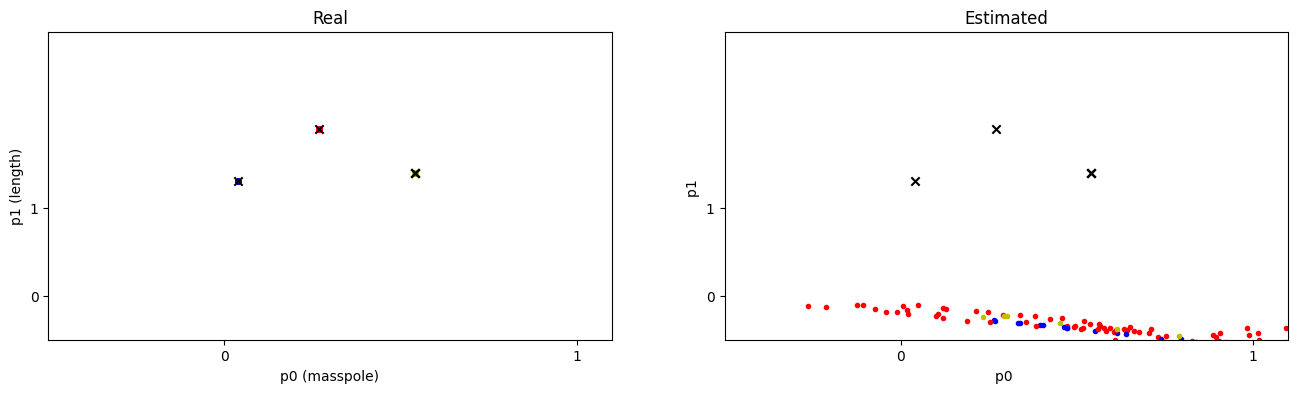

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
data.plot_clusters(axs, results)
plt.show()